In [1]:
# Imports

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load

df = pd.read_csv("data/weather.csv", usecols = ["time", "temperature_2m"], parse_dates = ["time"])
df.head()

,time,temperature_2m
0,2000-01-01 00:00:00,-4.5
1,2000-01-01 01:00:00,-4.5
2,2000-01-01 02:00:00,-4.6
3,2000-01-01 03:00:00,-4.7
4,2000-01-01 04:00:00,-6.9


In [3]:
# Inspect

# Structure
print(df["time"].min(), "to", df["time"].max(), "\n")
print("Shape:", df.shape, "\n")
print("Dtypes:")
print(df.dtypes, "\n")

# Missingness
print("Any Nulls:", df.isna().any().any(), "\n")

# Duplicates
print("Duplicate Rows:", df.duplicated().any(), "\n")
print("Duplicate Times:", df["time"].duplicated().any(), "\n")

# Sanity
print("Non-Monotonic Times:", not df["time"].is_monotonic_increasing, "\n")
print("Unexpected Time Deltas:", df["time"].diff().dropna().ne(pd.Timedelta(hours=1)).any())

2000-01-01 00:00:00 to 2026-08-31 23:00:00 

Shape: (233760, 2) 

Dtypes:
time              datetime64[us]
temperature_2m           float64
dtype: object 

Any Nulls: False 

Duplicate Rows: False 

Duplicate Times: False 

Non-Monotonic Times: False 

Unexpected Time Deltas: False


In [4]:
df[["temperature_2m"]].describe().T

,count,mean,std,min,25%,50%,75%,max
temperature_2m,233760.0,4.68828,11.519473,-42.9,-2.3,5.1,12.7,38.2


In [5]:
# Clean
# No clean required after inspection.

## Analytical Definition

For this analysis:

- Daytime is defined as 06:00 ≤ hour < 21:00.
- Overnight is defined as all remaining hours.
- The same fixed hour ranges are used for June, July, and August to keep the monthly comparison consistent.
- These are operational time-of-day definitions, not sunrise/sunset boundaries.

In [6]:
# Transform

summer_df = (
    df.loc[
        df["time"].between(
            "2025-06-01",
            "2025-09-01",
            inclusive="left"
        ),
        ["time", "temperature_2m"]
    ]
    .copy()
)

summer_df["month"] = summer_df["time"].dt.month

DAY_START_HOUR = 6
NIGHT_START_HOUR = 21

hour = summer_df["time"].dt.hour

daytime_mask = (
    hour.ge(DAY_START_HOUR)
    & hour.lt(NIGHT_START_HOUR)
)

summer_df["period"] = "Overnight"
summer_df.loc[daytime_mask, "period"] = "Daytime"

In [7]:
# Validate

# 92 days from June 1st through August 31 
assert len(summer_df) == 92 * 24

period_counts = (
    summer_df
    .groupby(
        ["month", "period"],
        as_index=False
    )
    .size()
)

period_counts

,month,period,size
0,6,Daytime,450
1,6,Overnight,270
2,7,Daytime,465
3,7,Overnight,279
4,8,Daytime,465
5,8,Overnight,279


In [8]:
monthly_df = (
    summer_df
    .groupby(
        ["month", "period"],
        as_index=False
    )
    .agg(
        mean_temp=("temperature_2m", "mean")
    )
)

monthly_df

,month,period,mean_temp
0,6,Daytime,17.228889
1,6,Overnight,11.877778
2,7,Daytime,17.544731
3,7,Overnight,13.501792
4,8,Daytime,19.286022
5,8,Overnight,13.641577


In [9]:
output_df = (
    monthly_df
    .pivot(
        index="month",
        columns="period",
        values="mean_temp"
    )
    .reindex([6, 7, 8])
    .rename(
        index={
            6: "June",
            7: "July",
            8: "August"
        }
    )
    .reset_index()
    .rename_axis(columns=None)
)

output_df

,month,Daytime,Overnight
0,June,17.228889,11.877778
1,July,17.544731,13.501792
2,August,19.286022,13.641577


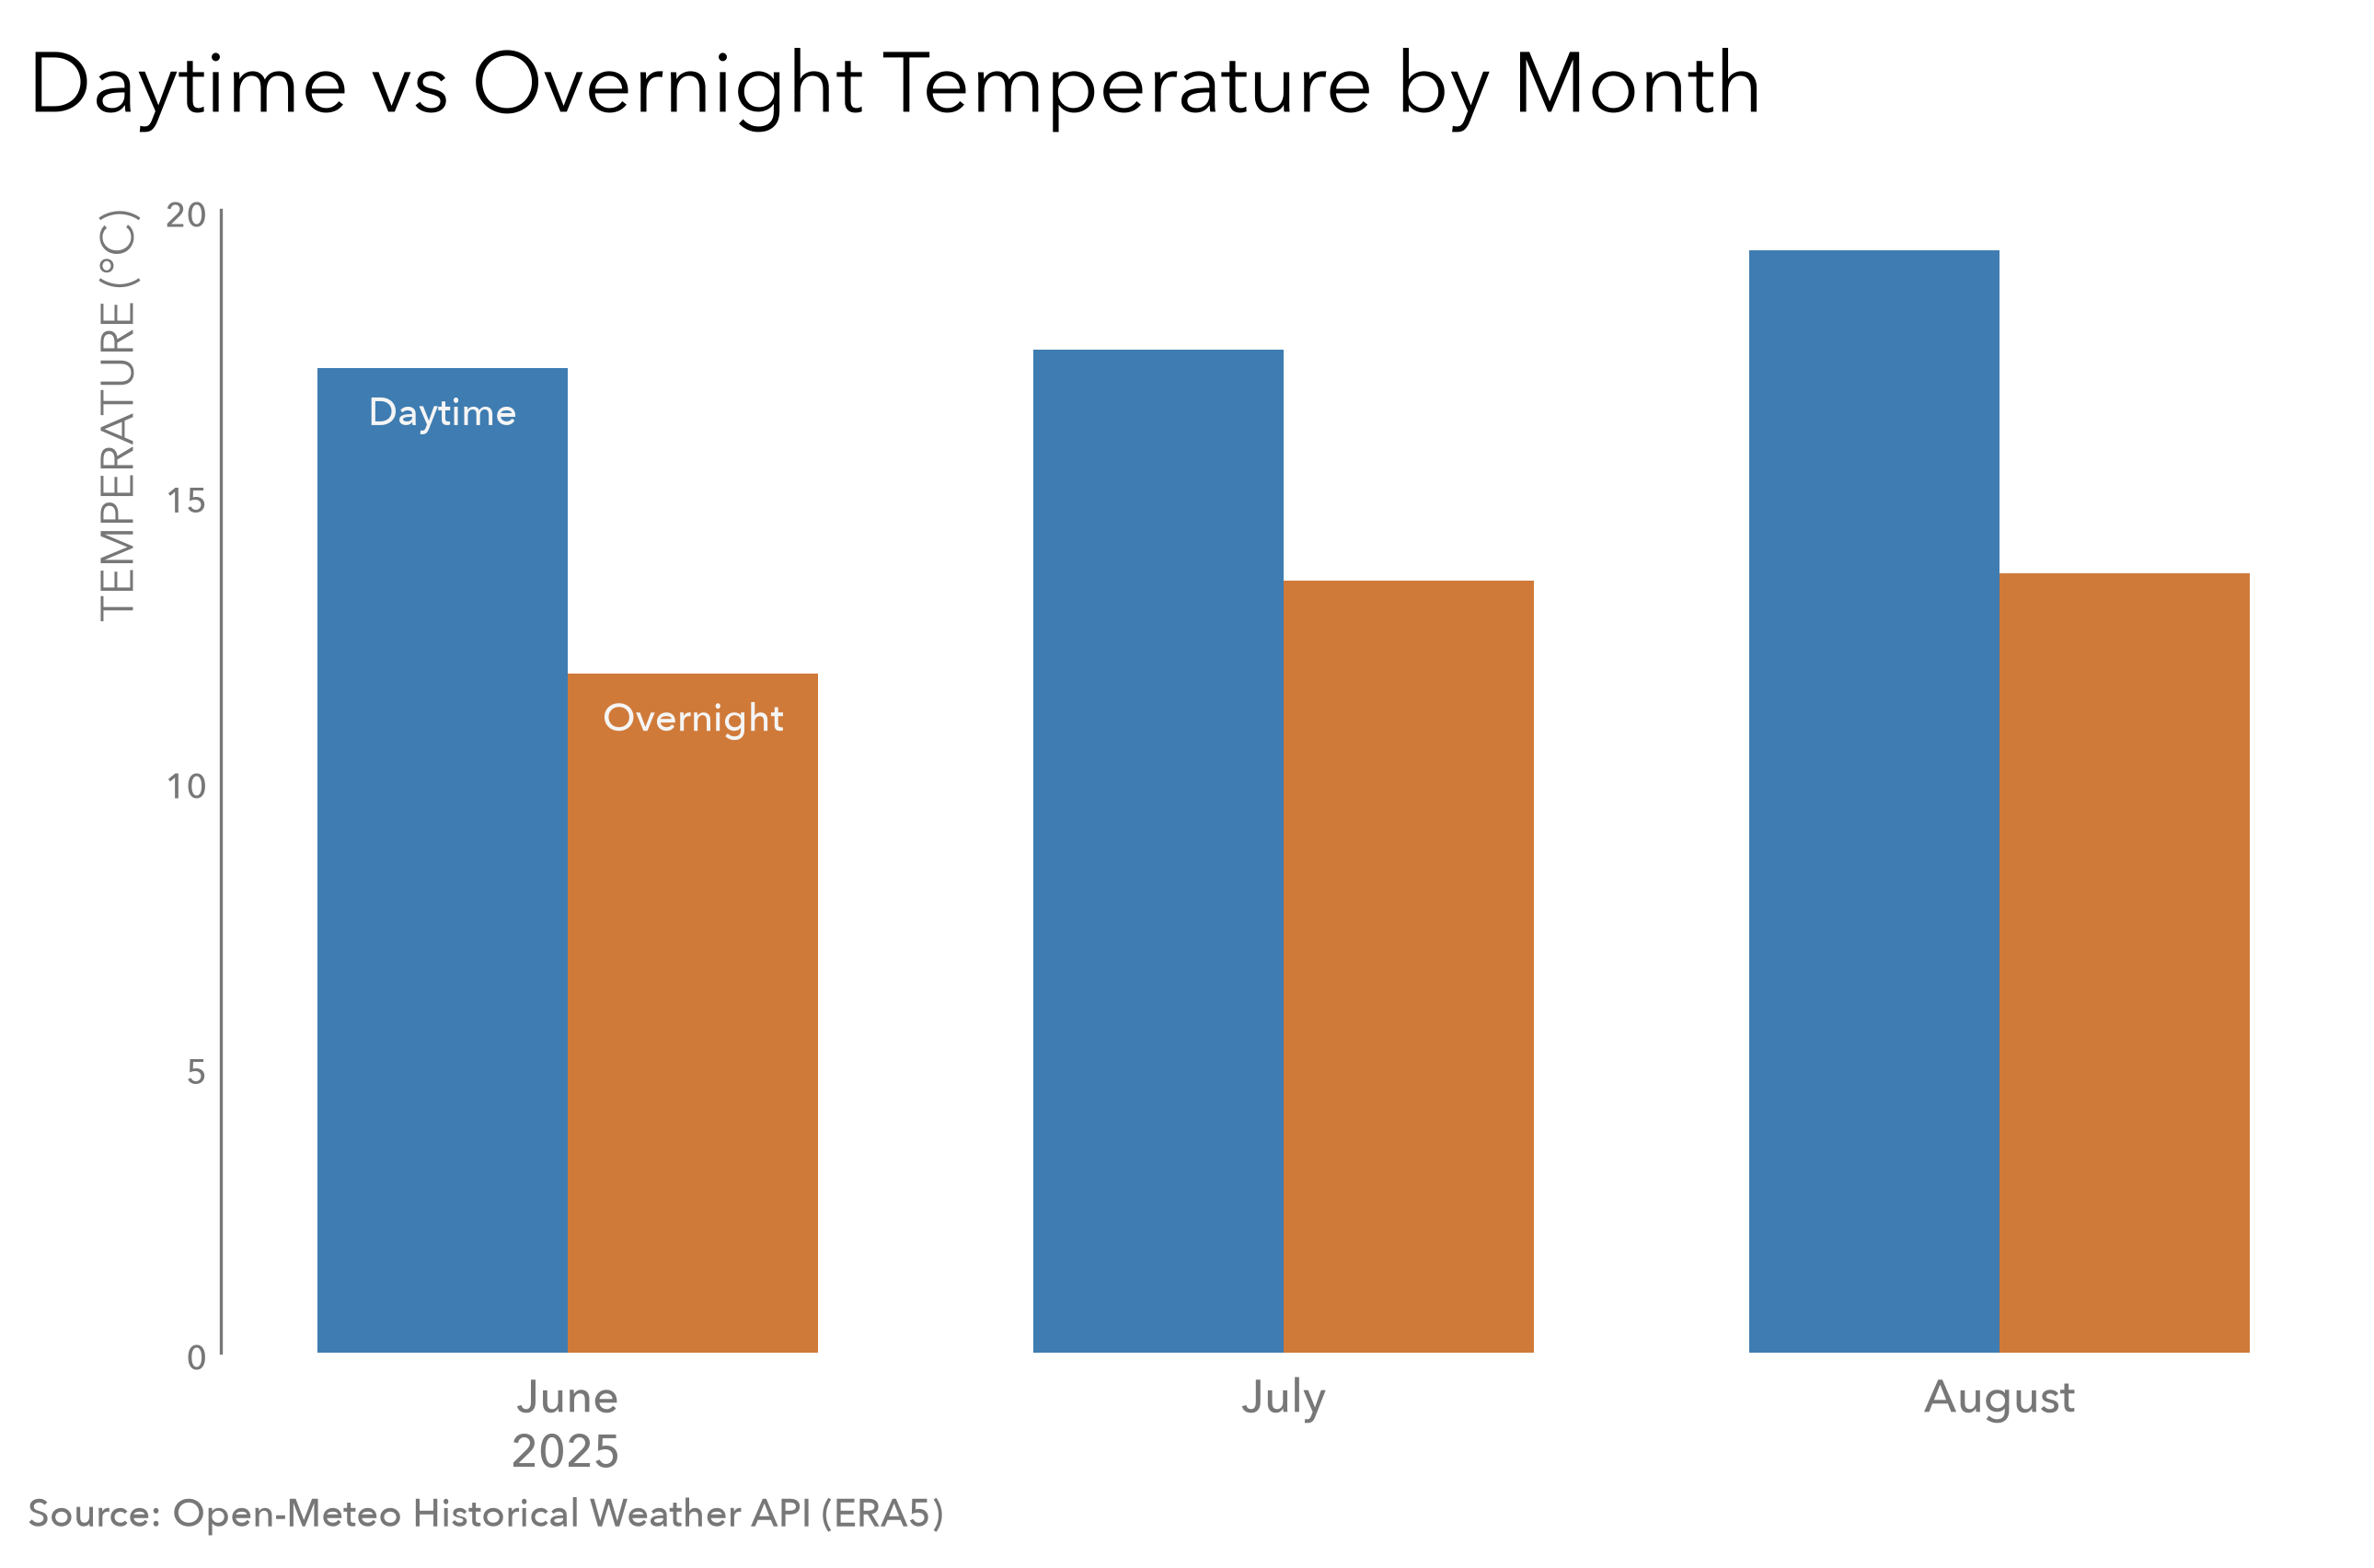

In [10]:
# Visualize

# Figure

plt.rcParams["font.family"] = "Avenir Next"
plt.rcParams["font.weight"] = 500

fig, ax = plt.subplots(figsize = (10, 6), dpi = 300)

fig.subplots_adjust(
    left = 0.13,
    right = 0.90,
    top = 0.83,
    bottom = 0.14
)

STRUCTURE = "#777777"
LABELTEXT = "#F5F5F5"
DAYTIME = "#3E7CB1"
OVERNIGHT = "#D07A3A"

# Plot

daytime_bars = ax.bar(output_df["month"], output_df["Daytime"], width = -0.35, align = "edge", color = DAYTIME)
overnight_bars = ax.bar(output_df["month"], output_df["Overnight"], width = 0.35, align = "edge", color = OVERNIGHT)

# Scale & Axes

ax.set_ylim(0, 20)

ax.set_ylabel("TEMPERATURE (°C)", loc = "top", fontsize = 12, fontweight = 400, color = STRUCTURE)

ax.text(-0.08, -0.10, "2025", transform=ax.get_xaxis_transform(), fontsize = 12, ha = "left", color = STRUCTURE)

# Ticks

ax.set_yticks([0, 5, 10, 15, 20])

ax.tick_params(axis = "x", labelsize = 12, length = 0, labelcolor = STRUCTURE)
ax.tick_params(axis = "y", labelsize = 9, length = 0, labelcolor = STRUCTURE)

# Styling

ax.spines[["top", "right", "bottom"]].set_visible(False)
ax.spines["left"].set_color(STRUCTURE)
ax.spines["left"].set_linewidth(0.8)

ax.text(daytime_bars[0].get_x() + daytime_bars[0].get_width() / 2, daytime_bars[0].get_height() - 1, "Daytime", ha = "center", fontsize = 10, color = LABELTEXT)
ax.text(overnight_bars[0].get_x() + overnight_bars[0].get_width() / 2, overnight_bars[0].get_height() - 1, "Overnight", ha = "center", fontsize = 10, color = LABELTEXT)

# Composition

fig.suptitle("Daytime vs Overnight Temperature by Month", x = 0.06, y = 0.94, ha = "left", va = "top", fontweight = 400, fontsize = 22)

fig.text(0.06, 0.035, "Source: Open-Meteo Historical Weather API (ERA5)", fontsize = 10, color = STRUCTURE)

# Output
fig.savefig("outputs/daytime-vs-overnight-temperature-summer-2025.svg", bbox_inches = "tight", pad_inches = 0.1)
plt.show()